In [1]:
import pandas as pd
import numpy as np
from st_supabase_connection import SupabaseConnection
import streamlit as st
%matplotlib inline
from matplotlib import pyplot as plt
from config import TABLE_PLAYERS, MEAN, STD_DEV, DIV_OPEN_LABEL, DIV_WOMEN_LABEL, SCHEMA

# Connect to DB
conn = st.connection("supabase", type=SupabaseConnection)
print(f"USING Schema: {SCHEMA}")
np.random.seed(42)

2026-04-19 09:03:40.944 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


USING Schema: prd


## Rating

In [2]:
def calculate_bell_prices(sub_df):
    """Sorts by total and maps to a normal distribution."""
    if sub_df.empty:
        return sub_df
        
    np.random.seed(42)
    # Sort by your new calculated total
    sub_df = sub_df.sort_values(by="total", ascending=False).reset_index(drop=True)
    num_players = len(sub_df)
    
    # Generate bell curve values
    bell_values = np.random.normal(loc=MEAN, scale=STD_DEV, size=num_players)
    bell_values = np.sort(bell_values)[::-1] # Highest total gets highest bell price
    
    sub_df["price"] = bell_values.round(1)  #.astype(int)
    sub_df["price"] = sub_df["price"].clip(lower=3) # Floor price
    
    # Consistency check: tie-breaks for 'total' get the same price
    # sub_df["price"] = sub_df.groupby("total")["price"].transform("max")
    return sub_df


def run_full_pricing_sync():
    """Consolidated logic: Scale contributions -> Calculate Totals -> Apply Bell Curve."""
    try:
        # 1. Fetch Data
        res = conn.client.schema(SCHEMA).table(TABLE_PLAYERS).select("*").eq("has_submitted_rank", True).execute()
        df = pd.DataFrame(res.data)

        if df.empty:
            print("No player data found to price.")
            return

        # 2. Team-Based Scaling (Your new logic)
        df['contribution'] = df['avg_goals'] + df['avg_assists']
        df['team_total'] = df.groupby('team')['contribution'].transform('sum')
        df['submission_count'] = df.groupby('team')['id'].transform('count')

        # Scaling factor with sqrt damping
        df['scaling_factor'] = np.sqrt(df['submission_count'] / 10.0)
        mask = df['team_total'] > 30
        df.loc[mask, 'scaling_factor'] = (30.0 / df['team_total']) * df['scaling_factor']

        # Calculate the normalized 'Total'
        df['scaled_contrib'] = np.ceil(df['contribution'] * df['scaling_factor'])
        df['total'] = (
            df['scaled_contrib'] + 
            df['throwing'] + 
            df['game_iq'] + 
            df['athleticism']
        )

        # 3. Apply Bell Curve per Division
        # Ensure division strings match labels exactly (case-insensitive)
        open_mask = df["division"].str.lower() == DIV_OPEN_LABEL.lower()
        women_mask = df["division"].str.lower() == DIV_WOMEN_LABEL.lower()

        open_df = calculate_bell_prices(df[open_mask].copy())
        women_df = calculate_bell_prices(df[women_mask].copy())
        
        final_df = pd.concat([open_df, women_df])
        return final_df

    except Exception as e:
        print(f"Error during pricing sync: {e}")

In [3]:
df = run_full_pricing_sync()

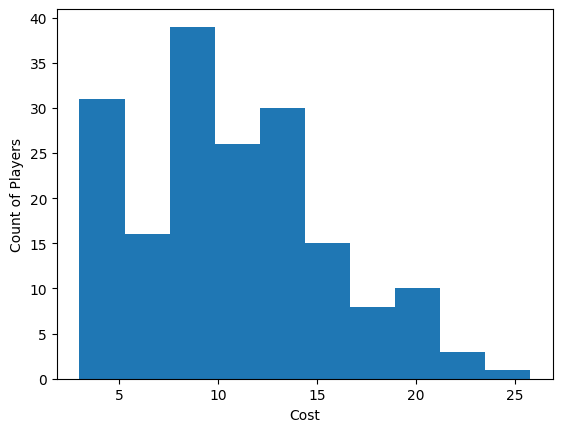

In [4]:
plt.hist(df['price'])
plt.ylabel("Count of Players")
plt.xlabel("Cost")
plt.show()

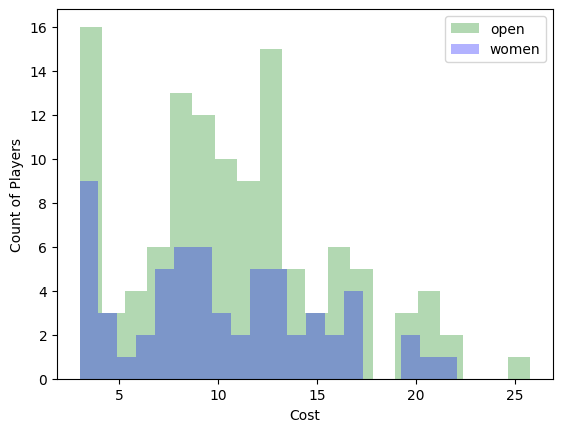

In [5]:
plt.hist(df[df["division"] == "Opens"]['price'], bins=20, color="green", alpha=0.3, label="open")
plt.hist(df[df["division"] == "Womens"]['price'], bins=20, color="blue", alpha=0.3, label="women")
plt.ylabel("Count of Players")
plt.xlabel("Cost")
plt.legend()

In [6]:
df[df["division"] == "Opens"][["name", "price"]].head(30)

,name,price
0,Pieter Conradie,25.8
1,Siya Mhlongo,22.3
2,Tando Sazi Khoza,22.1
3,Corné Badenhorst,20.5
4,Genius Muzama,20.4
5,Chase Roodt,20.2
6,Scott Glennie,20.1
7,Sammy Harris,19.9
8,Breyten Van der Merwe,19.8
9,Abel Escobar,19.1


In [7]:
df[df["division"] == "Womens"][["name", "price"]].head(30)

,name,price
0,Eliza Stewart,22.1
1,Lazya Greyvenstein,20.5
2,Lauren Immelman,20.1
3,Christine Anderson,19.8
4,Dana Ivey,17.3
5,Kelly Paxton,17.2
6,Alexandra Wattamaniuk,16.9
7,Tara Walmsley,16.6
8,Aloise Wepener,15.9
9,Lyndall Voss-Price,15.6


In [8]:
df[["name", "price"]].tail(20)

,name,price
42,Nana Songca-Abrebeseh,7.7
43,Christine Mitchell,7.6
44,Sarah Levin,7.4
45,Hannah Allan,7.4
46,Tracey Hill,6.9
47,Sharise Smith,6.7
48,Abi Bray,6.0
49,Ella Vorster,5.6
50,Alexandra Davidge,4.9
51,Michelle Paxton,4.7


In [19]:
df.to_csv("data/test.csv", index=False)